In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams.update({
    'font.family': 'Arial'
})
import os
import shutil
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import re
import scipy.stats as stats
import matplotlib.lines as mlines
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import minmax_scale
from statsmodels.stats.multitest import multipletests
from skbio.stats.composition import clr,multi_replace
pd.set_option('display.max_columns', 500)
import statsmodels.formula.api as smf
import sys
sys.path.append('/Volumes/T9/LUMIN/lumin')
import matplotlib.colors as mcolors

import plot as plot  # now you can import plot.py
import utils as utils
import activity
import pickle


In [2]:
response_df = pd.read_pickle('/Volumes/T9/Ca_data/exp_stimulated/Analysis_revision/Quantification/Control_vs_NMDA/Tables/Control_vs_NMDA_percentage_responding_per_replicate.pkl')
cluster_df = pd.read_pickle('/Volumes/T9/Ca_data/exp_stimulated/Analysis_revision/Quantification/Tables/stimulation_to_cluster.pkl')
cell_properties_df = pd.read_pickle('/Volumes/T9/Ca_data/exp_stimulated/Analysis_revision/Quantification/Tables/cell_properties_baseline_change.pkl')
kcl_df = pd.read_pickle('/Volumes/T9/Ca_data/exp_stimulated/Analysis_revision/Quantification/Tables/kcl_auc_per_well.pkl')

palette = dict(cell_properties_df[['stimulation', 'colors']].drop_duplicates().values)

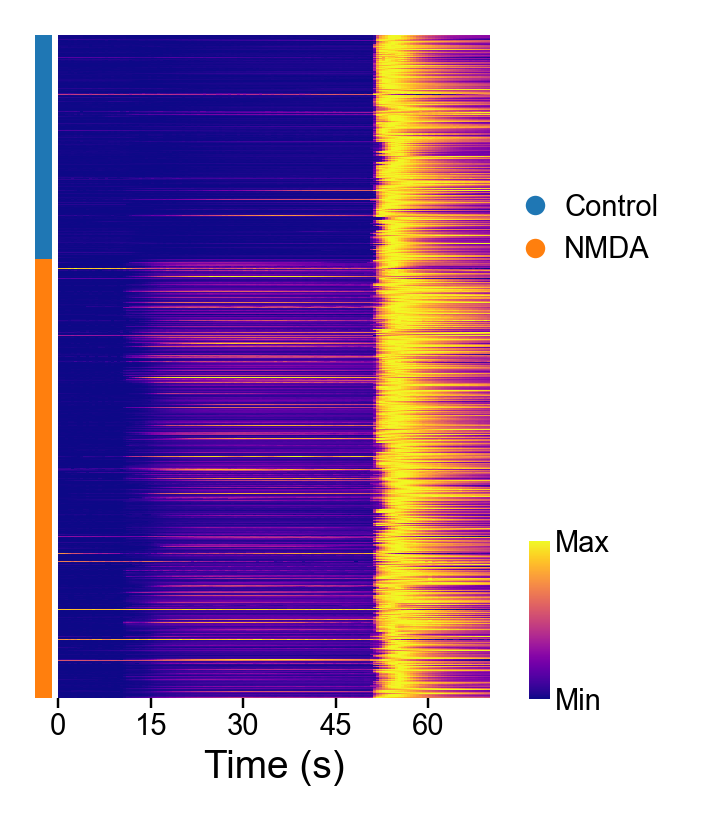

In [6]:

plot.heatmap(cell_properties_df=cell_properties_df,   imaging_interval=0.5,  cmap = 'plasma', palette = palette,minmax_bool=True)
plt.savefig('Fig4/fig4c_heatmap.pdf',  bbox_inches='tight')
plt.show()

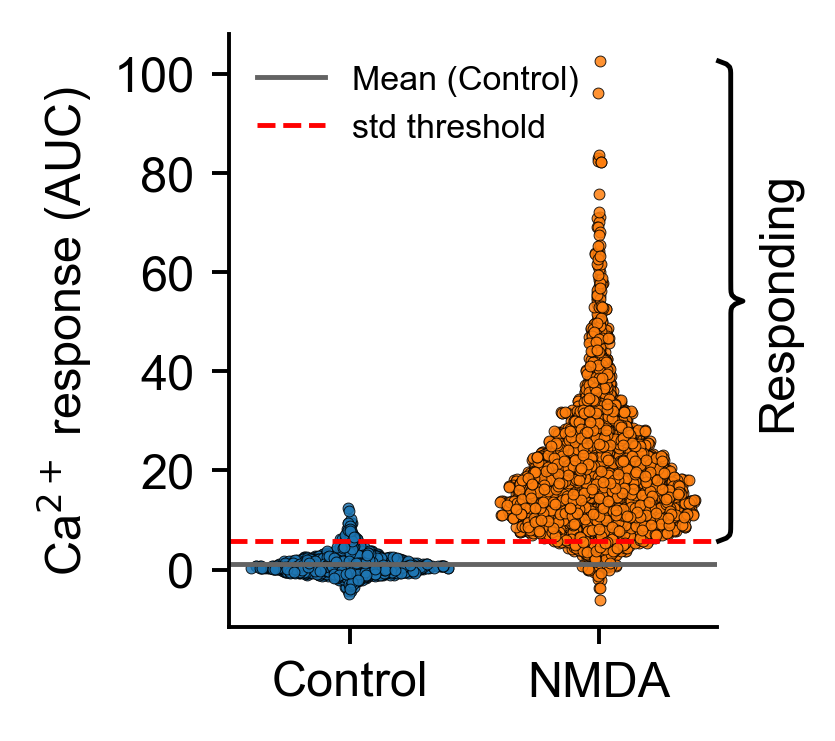

In [40]:
subset_df = cell_properties_df[cell_properties_df.biological_replicate == 'KL08'].copy()
subset_df["stimulation"] = subset_df["stimulation"].cat.remove_unused_categories()

# Beeswarm
with plt.rc_context({"figure.dpi": 350, "figure.figsize": (1.8, 2.2)}):

    ax_beeswarm = plot.beeswarm(cell_properties_df=subset_df, control_condition='Control',  std_threshold=3,   brace=True, x='stimulation', y='AUC', control_condition_mean=True)
    plt.ylabel(r"Ca$^{2+}$ response (AUC)")
    plt.legend(loc='upper right', frameon=False, fontsize=7, bbox_to_anchor=(0.78,1))
    plt.savefig(os.path.join('Fig4/fig4d_beeswarm.pdf'),  bbox_inches='tight')
    plt.show()
    #plt.close()        

<Figure size 630x770 with 0 Axes>

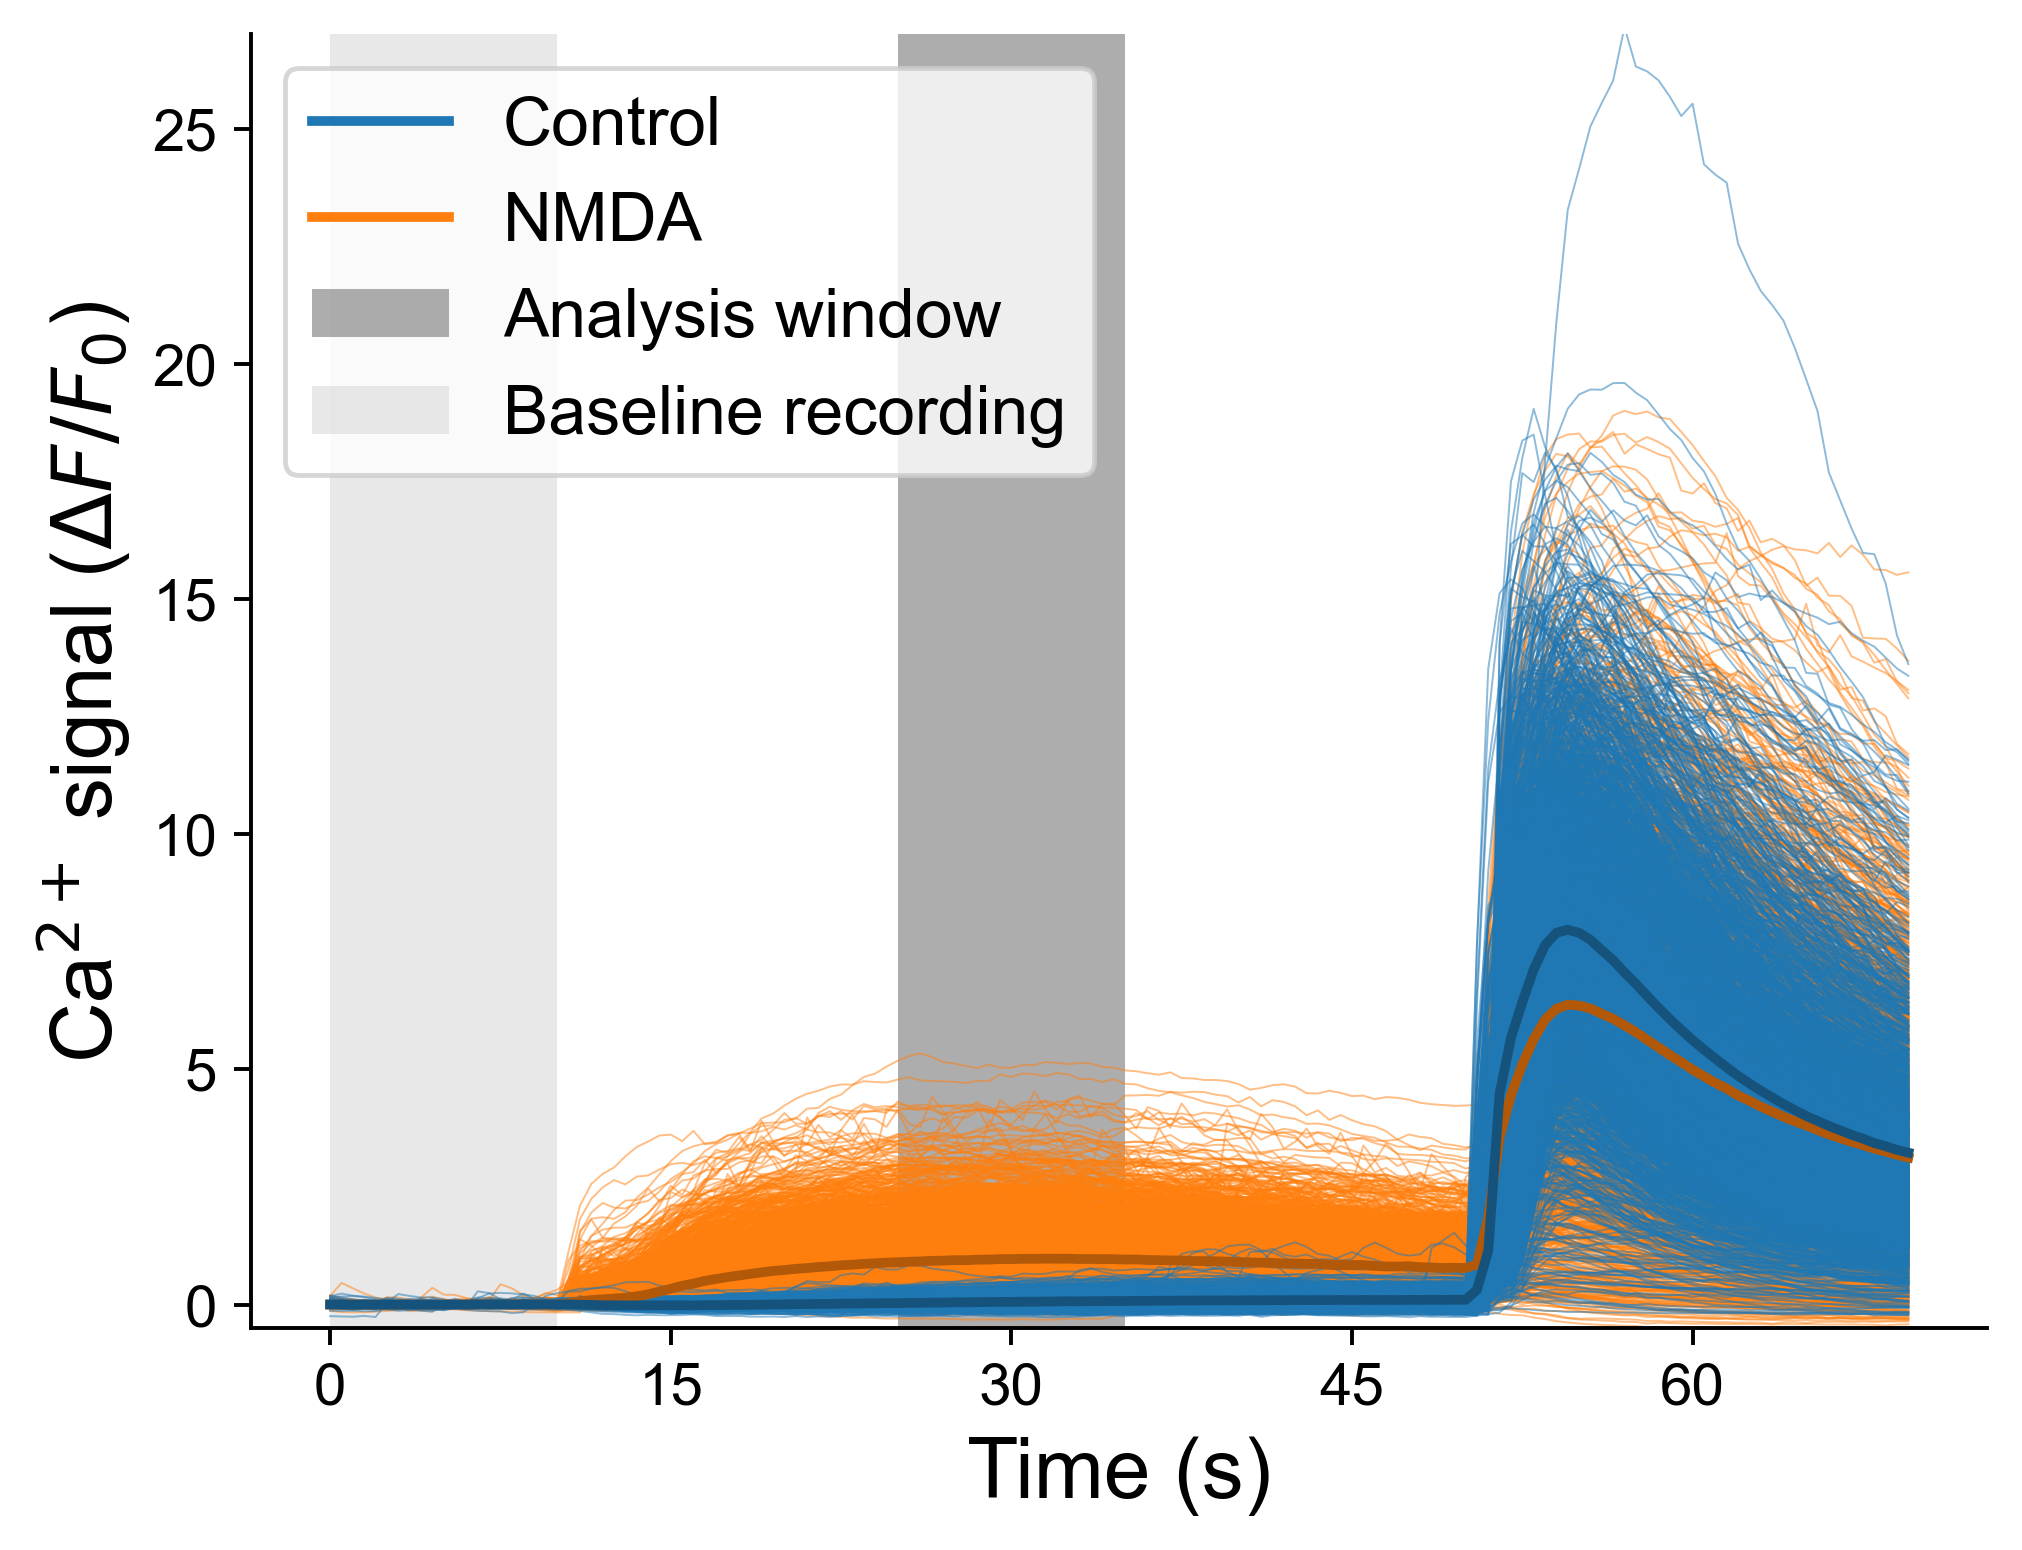

In [7]:
plot.overlaid_traces_two_groups(cell_properties_df = subset_df,  control_condition = 'Control', treatment_condition= 'NMDA', trace='dff', mean=True, start_frame= 50, end_frame = 70, stimulation_frame = 20,   imaging_interval=0.5)
#plt.ylim(0,20)
plt.ylim(-0.5,27)
plt.savefig(os.path.join('Fig4/fig4b_lineplot.pdf'),  bbox_inches='tight')

plt.show()

# Statistical test for NMDA response

In [89]:
# Test if for equal variance

values_dict = {}
for stim in response_df.stimulation.cat.categories:
    values_dict[stim] = response_df[response_df.stimulation == stim]['proportion_positive_cells'].tolist()

stat, p = stats.levene(*list(values_dict.values()))
print(p)

0.1506473292901686


Control: ShapiroResult(statistic=0.9238868106673102, pvalue=0.46617225999422723)


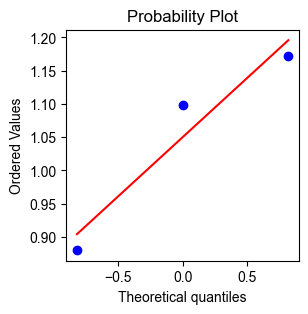

NMDA: ShapiroResult(statistic=0.9770368442778027, pvalue=0.7094683393584319)


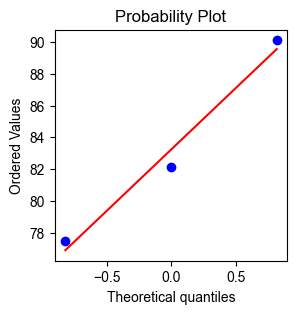

In [90]:
# Test for normality

for key, values in values_dict.items():
    print(f'{key}: {stats.shapiro(values)}')
    
    plt.figure(figsize=(3, 3))
    stats.probplot(values, dist="norm", plot=plt)
    plt.show()
    

In [94]:
# Run t-test
t_stat, p_value = stats.ttest_rel(list(values_dict.values())[0], list(values_dict.values())[1])
p_value

0.0019617916436736487

In [11]:
# Mean
print('control', round(np.mean(response_df[response_df.stimulation == "Control"].proportion_positive_cells.values),2))
print('NMDA', round(np.mean(response_df[response_df.stimulation == "NMDA"].proportion_positive_cells.values), 2))

control 1.05
NMDA 83.22


In [12]:
# Std
print('control', np.std(response_df[response_df.stimulation == "Control"].proportion_positive_cells.values))
print('NMDA', np.std(response_df[response_df.stimulation == "NMDA"].proportion_positive_cells.values))

control 0.12388016910020866
NMDA 5.228806974496495


# Percentage responding cells barplot

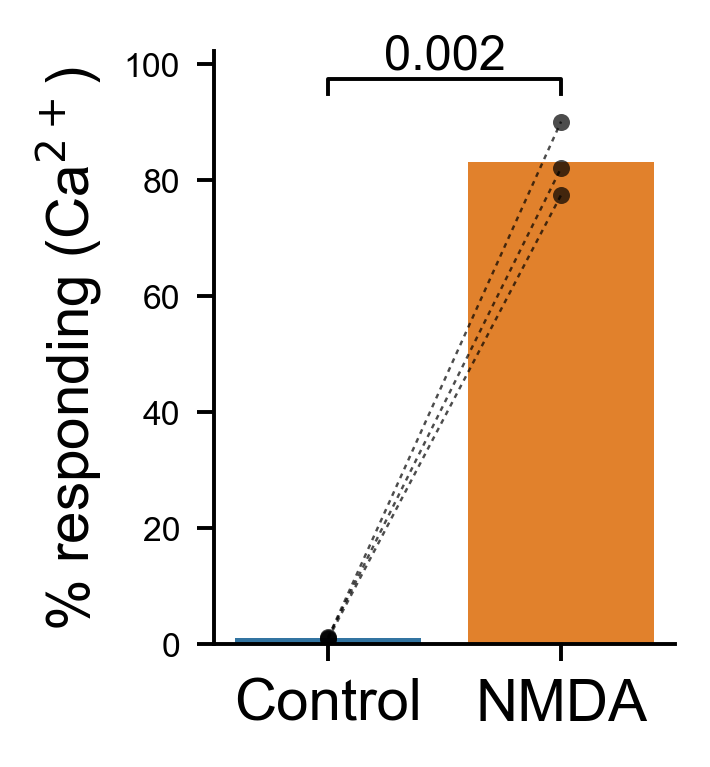

In [13]:
with plt.rc_context({"figure.dpi": 350, "figure.figsize": (1.7, 2.2)}):

    ax = plot.two_conditions_barplot(response_perc_mean_df=response_df, palette = palette, x='stimulation',y='proportion_positive_cells')
    plt.ylabel(r"% responding (Ca$^{2+}$)", fontsize='large')
    
    x1, x2 = 0, 1   
    y, h, col = response_df['proportion_positive_cells'].max() + 4.8, 2.5, 'k'
    
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=col)
    plt.text((x1+x2)*.5, y+h, round(p_value,4), ha='center', va='bottom', color=col)
    ax.spines['right'].set_color(None)
    ax.spines['top'].set_color(None)
    plt.savefig('Fig4/fig_4e_responding_cells_barplot.pdf',  bbox_inches='tight')
    plt.show()

# Cluster centroid line plot

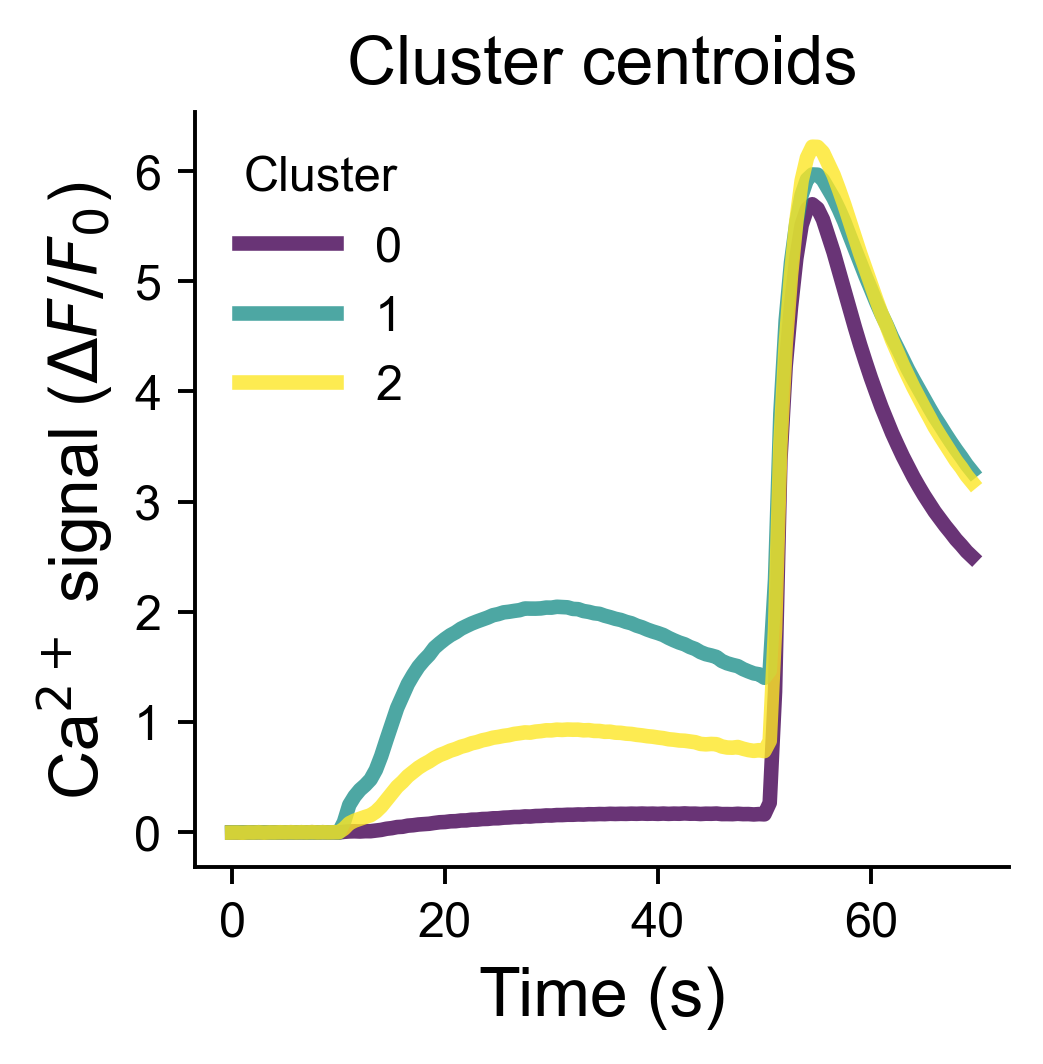

In [14]:
imaging_interval=0.5

cluster_dict, colors_dict = utils.cluster_centroids(cell_properties_df=cell_properties_df)

with plt.rc_context({"figure.dpi": (350), 'figure.figsize':(3, 2.8)}):

    ax= plot.cluster_centroids(cluster_dict=cluster_dict,palette=colors_dict, imaging_interval = imaging_interval, alpha=0.8)
    plt.savefig('Fig4/fig_4g_cluster_centroids.pdf',  bbox_inches='tight')
    plt.show()

# Cluster barplot

In [21]:
cluster_df['id'] = cluster_df.index

id_list, clr_list = [],[]

for stim in cluster_df.stimulation.unique():
    for rep in cluster_df.biological_replicate.unique():
        df_sub = cluster_df[(cluster_df.stimulation == stim) & (cluster_df.biological_replicate == rep)]
        values = multi_replace(df_sub['proportion'].mul(0.01).tolist(), delta=0.0001)
        
        id_list.extend(df_sub['id'].tolist())
        clr_list.extend(clr(values).tolist())

cluster_df['clr_transformed'] = cluster_df['id'].map(dict(zip(id_list, clr_list)))
cluster_df

,stimulation,biological_replicate,cluster,proportion,cluster_color,id,clr_transformed
0,Control,KL06,0,99.908925,#440154,0,5.403221
1,Control,KL06,2,0.091075,#fde725,1,-1.597113
2,Control,KL06,1,0.000000,#21918c,2,-3.806108
3,Control,KL08,0,99.802567,#440154,3,5.144604
4,Control,KL08,2,0.197433,#fde725,4,-1.080944
5,Control,KL08,1,0.000000,#21918c,5,-4.063660
6,Control,KL09,0,99.770115,#440154,6,5.093661
7,Control,KL09,2,0.229885,#fde725,7,-0.979383
8,Control,KL09,1,0.000000,#21918c,8,-4.114278
9,NMDA,KL06,2,42.895805,#fde725,9,0.348072


In [22]:
cluster_dict = {'0':[cluster_df[(cluster_df.stimulation == 'Control') & (cluster_df.cluster == 0)].clr_transformed.tolist(),
              cluster_df[(cluster_df.stimulation == 'NMDA') & (cluster_df.cluster == 0)].clr_transformed.tolist()],
 '1':[cluster_df[(cluster_df.stimulation == 'Control') & (cluster_df.cluster == 1)].clr_transformed.tolist(),
           cluster_df[(cluster_df.stimulation == 'NMDA') & (cluster_df.cluster == 1)].clr_transformed.tolist()],
 '2':[cluster_df[(cluster_df.stimulation == 'Control') & (cluster_df.cluster == 2)].clr_transformed.tolist(),
     cluster_df[(cluster_df.stimulation == 'NMDA') & (cluster_df.cluster == 2)].clr_transformed.tolist()]}
cluster_dict

{'0': [[5.403221221818944, 5.144604040069388, 5.093661134695991],
  [0.31493150082768584, -0.1739986876873134, 0.10870513899691336]],
 '1': [[-3.8061079833626588, -4.063660041678249, -4.114277735291578],
  [-0.6630033941576761, -0.6204378700057835, -0.7146706237988716]],
 '2': [[-1.597113238456286, -1.0809439983911382, -0.9793833994044139],
  [0.3480718933299901, 0.7944365576930967, 0.6059654848019581]]}

In [23]:
cluster = '0'

stat, p = stats.levene(*list(cluster_dict[cluster]))
print(p)

0.6325417233033087


0: ShapiroResult(statistic=0.8695487691194568, pvalue=0.2942432719553896)


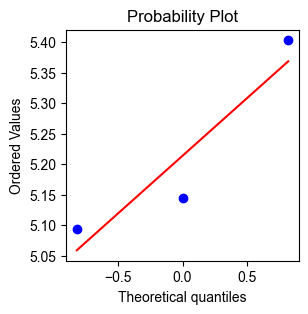

0: ShapiroResult(statistic=0.9919104480199493, pvalue=0.8279911079133795)


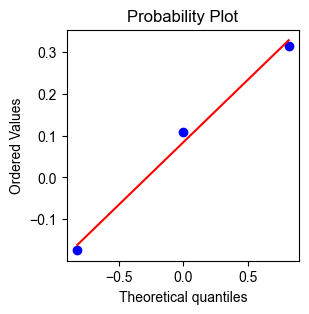

In [24]:
# Test for normality

for values in cluster_dict[cluster]:
    print(f'{cluster}: {stats.shapiro(values)}')
    
    plt.figure(figsize=(3, 3))
    stats.probplot(values, dist="norm", plot=plt)
    plt.show()

In [19]:
pvalue_dict = {}

for c in cluster_dict.keys():

    t_stat, pvalue_dict[int(c)] = stats.ttest_rel(cluster_dict[c][0], cluster_dict[c][1])

reject, pvals_corrected, _, _ = multipletests(list(pvalue_dict.values()), alpha=0.05, method='fdr_bh')

for i, v in enumerate(pvals_corrected):
    pvalue_dict[i] = round(v, 3)

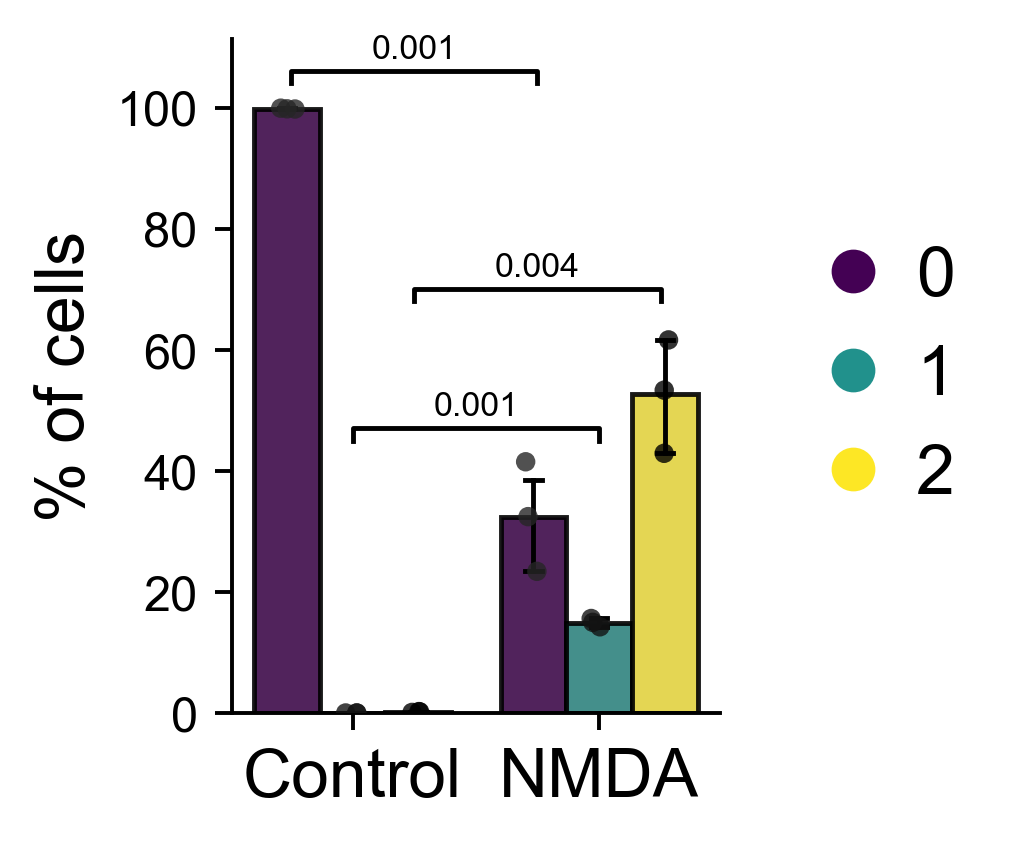

In [23]:
colors_dict = dict(cluster_df[['cluster', 'cluster_color']].drop_duplicates().values.tolist())

with plt.rc_context({"figure.dpi": (350), 'figure.figsize':(1.8, 2.5)}):

    ax_cluster_barplot = plot.all_conditions_barplot(dataframe=cluster_df, palette=colors_dict, ycolumn='proportion',xcolumn='stimulation',hue='cluster', alpha=0.9)
    ax_cluster_barplot.set_ylabel('% of cells', fontsize=14)
    ax_cluster_barplot.set_xlabel('')
    ax_cluster_barplot.set_xlabel('')
    ax_cluster_barplot.tick_params(axis='x',  labelsize=14)

    plt.plot([-0.25, -0.25, 0.75 , 0.75 ], [104, 104+2, 104+2, 104], lw=1, c='k')
    plt.text((-0.25+0.75)*.5, 104+3, pvalue_dict[0], ha='center', va='bottom', color='k', size=7)

    plt.plot([0, 0, 1 , 1 ], [45, 45+2, 45+2, 45], lw=1, c='k')
    plt.text((0+1)*.5, 45+3, pvalue_dict[1], ha='center', va='bottom', color='k', size=7)

    plt.plot([0.25, 0.25, 1.25 , 1.25 ], [68, 68+2, 68+2, 68], lw=1, c='k')
    plt.text((0.25+1.25)*.5, 68+3, pvalue_dict[2], ha='center', va='bottom', color='k', size=7)
    
    plt.savefig('Fig4/fig_4g_stimulation_to_cluster_barplot.pdf',  bbox_inches='tight')
    
    
    plt.show()

# ICC analysis

In [25]:
cell_properties_df = pd.read_pickle('/Volumes/T9/Ca_data/exp_stimulated/ICC_analysis/Analysis/Quantification/Tables/cell_properties_baseline_change.pkl')
min_val = cell_properties_df["AUC"].min()
cell_properties_df["AUC_log"] = cell_properties_df["AUC"] + abs(min_val) + 1e-6
cell_properties_df["AUC_log"] = np.log1p(cell_properties_df["AUC_log"])
cell_properties_df

,label,centroid-0,centroid-1,ca_intensity,area,raw,image_id,biological_replicate,stimulation,filename,plate_id,mask_path,filepath,plate_id_biological_replicate,marker,dff,baseline,colors,AUC_kcl,AUC,response,cluster,cluster_color,AUC_log
0,1,941.712934,771.394322,0.374441,317.0,"[40.95583596214511, 39.630914826498426, 40.552...",B02_plate #5,KL08,Control,B02,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL08,MAP2,"[0.010833978908193433, -0.021866496416572782, ...","[40.51687697160883, 40.51687697160883, 40.5168...",#1c1fb0,194.893354,-0.183201,no response,0,#440154,1.563638
289,20,939.906752,1519.369775,1.000000,311.0,"[148.17041800643088, 150.37299035369776, 148.6...",C02_plate #5,KL08,Control,C02,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL08,MAP2,"[-0.01668693852292864, -0.0020698632183173355,...","[150.6848874598071, 150.6848874598071, 150.684...",#1c1fb0,296.076777,1.702793,no response,0,#440154,1.896443
288,19,1637.529968,1528.192429,0.946296,317.0,"[219.13564668769715, 219.5583596214511, 216.51...",C02_plate #5,KL08,Control,C02,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL08,MAP2,"[-0.004904141123519153, -0.0029845999798020443...","[220.21561514195588, 220.21561514195588, 220.2...",#1c1fb0,85.922773,-1.762382,no response,0,#440154,1.162207
287,18,1637.500000,1501.500000,0.991051,316.0,"[119.8006329113924, 119.68037974683544, 119.46...",C02_plate #5,KL08,Control,C02,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL08,MAP2,"[0.005058878657266495, 0.004050023296594113, 0...","[119.19762658227849, 119.19762658227849, 119.1...",#1c1fb0,240.800553,1.863781,no response,0,#440154,1.920321
286,17,1643.455414,1183.101911,1.000000,314.0,"[194.38216560509554, 196.01273885350318, 194.0...",C02_plate #5,KL08,Control,C02,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL08,MAP2,"[-0.008064070519175272, 0.0002567761269709731,...","[195.9624203821656, 195.9624203821656, 195.962...",#1c1fb0,290.500063,5.031057,no response,0,#440154,2.301627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,5,447.610759,837.221519,0.762014,316.0,"[179.50316455696202, 181.06962025316454, 180.4...",C07_plate #5,KL09,NMDA,C07,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL09,MAP2,"[-0.005630721440567194, 0.003046760231539659, ...","[180.51962025316456, 180.51962025316456, 180.5...",#f5ce51,120.780763,12.024045,above,0,#440154,2.832237
448,6,414.656151,888.302839,0.828304,317.0,"[105.88643533123029, 103.49842271293376, 104.9...",C07_plate #5,KL09,NMDA,C07,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL09,MAP2,"[0.008115137644988323, -0.01462046264093361, -...","[105.03406940063091, 105.03406940063091, 105.0...",#f5ce51,323.605800,17.433490,above,1,#21918c,3.108742
449,7,316.470032,822.192429,0.987750,317.0,"[192.5646687697161, 198.51104100946372, 194.91...",C07_plate #5,KL09,NMDA,C07,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL09,MAP2,"[-0.016601287183741875, 0.013765938766140106, ...","[195.81545741324922, 195.81545741324922, 195.8...",#f5ce51,214.665244,5.466616,above,0,#440154,2.344301
451,9,313.853035,35.658147,1.000000,313.0,"[581.0159744408945, 586.3929712460064, 581.648...",C07_plate #5,KL09,NMDA,C07,plate #5,/Volumes/T9/Ca_data/exp_stimulated/ICC_analysi...,/Volumes/T9/Ca_data/exp_stimulated/image_stack...,plate #5_KL09,MAP2,"[1.7046557447417856e-05, 0.009271677584711499,...","[581.0060702875401, 581.0060702875401, 581.006.

In [26]:
model = smf.mixedlm("AUC_log ~ C(stimulation) * C(marker)", data=cell_properties_df, groups=cell_properties_df['biological_replicate'])
fit = model.fit(method='lbfgs') 
print(fit.summary())

                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         AUC_log  
No. Observations:           1094            Method:                     REML     
No. Groups:                 3               Scale:                      0.2697   
Min. group size:            265             Log-Likelihood:             -844.5847
Max. group size:            478             Converged:                  Yes      
Mean group size:            364.7                                                
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               1.849    0.043 42.569 0.000  1.764  1.935
C(stimulation)[T.NMDA]                  1.294    0.037 35.153 0.000  1.222  1.366
C(marker)[T.TH]                       

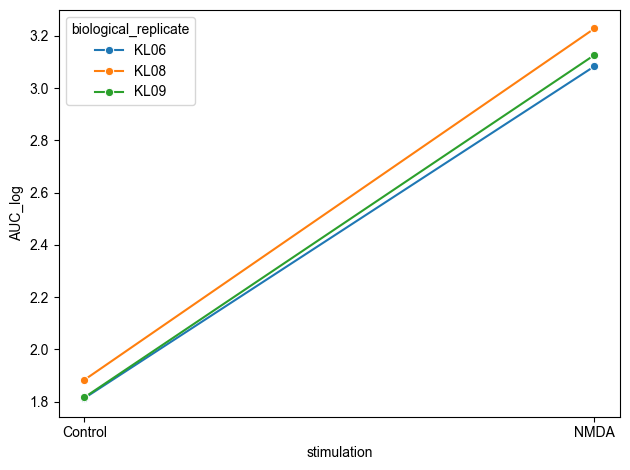

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


    
sns.lineplot(
    data=cell_properties_df,
    x="stimulation",
    y='AUC_log',
    hue="biological_replicate",
    estimator="mean",
    ci=None,
    marker="o",

)

plt.tight_layout()
plt.show()

In [29]:
import numpy as np

# Number of fixed effects
k_fe = fit.k_fe  

# Build a row vector with the right length
contrast = np.zeros((1, k_fe))

# Fill in the coefficients you want to test
contrast[0, fit.model.exog_names.index("C(stimulation)[T.NMDA]")] = 1
contrast[0, fit.model.exog_names.index("C(stimulation)[T.NMDA]:C(marker)[T.TH]")] = 1

# Run the test
res = fit.t_test(contrast)
print(res)
print(res.pvalue)

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.3317      0.076     17.424      0.000       1.182       1.481
5.4121381751265796e-68


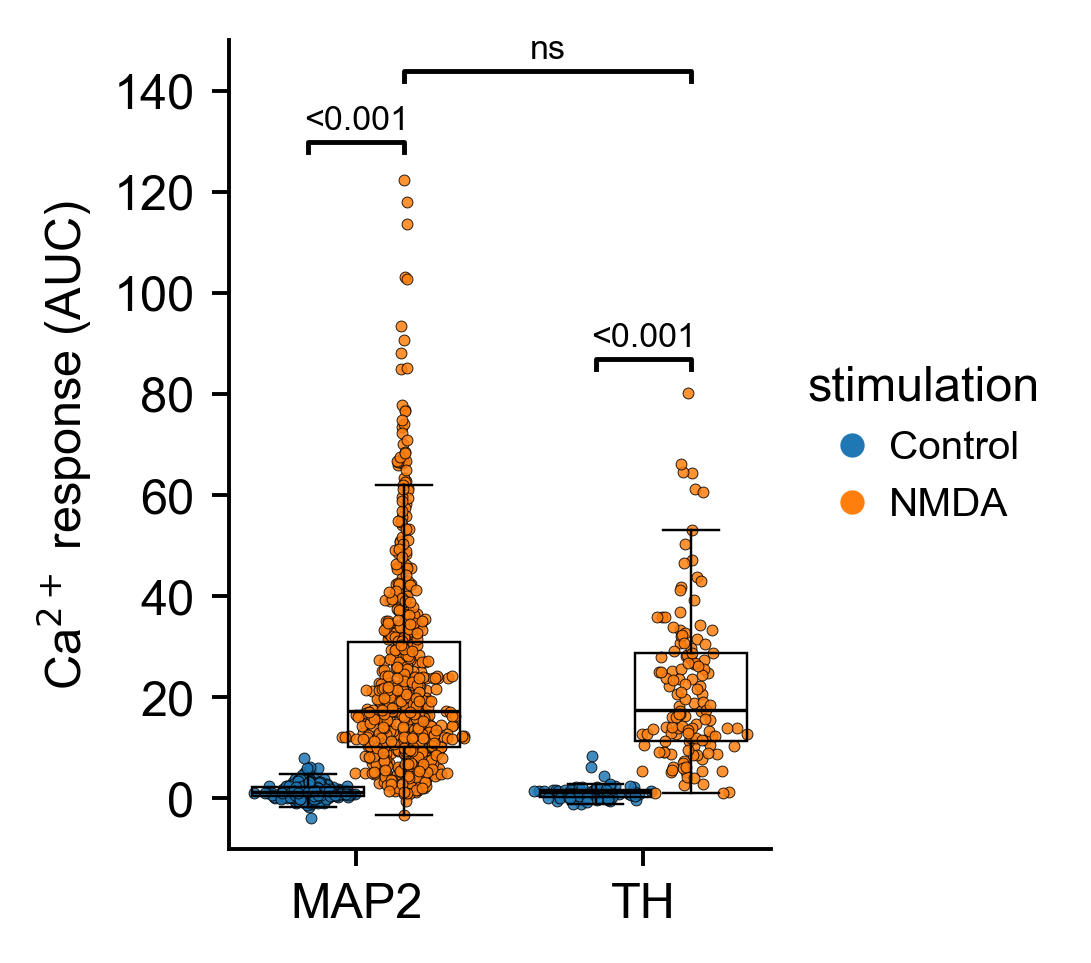

In [63]:
with plt.rc_context({"figure.dpi": (350), 'figure.figsize':(2.0, 3)}):

    ax = plot.beeswarm(cell_properties_df, x="marker", y='AUC',hue='stimulation', ax=None, separation_between_plots=1.8)
    plt.ylim(-10, 150)
    plt.plot([1.5, 1.5, 2.1 , 2.1 ], [128, 128+2, 128+2, 128], lw=1, c='k')
    plt.text((1.5+2.1)*.5, 128+3, '<0.001', ha='center', va='bottom', color='k', size=7)

    plt.plot([2.1, 2.1,3.9 , 3.9 ], [142, 142+2, 142+2, 142], lw=1, c='k')
    plt.text((2.1+3.9)*.5, 142+3, 'ns', ha='center', va='bottom', color='k', size=7)

    plt.plot([3.3, 3.3, 3.9 , 3.9 ], [85, 85+2, 85+2, 85], lw=1, c='k')
    plt.text((3.3+3.9)*.5, 85+3, '<0.001', ha='center', va='bottom', color='k', size=7)
    plt.ylabel(r"Ca$^{2+}$ response (AUC)")
    #plt.ylim(0,20)
    
    plt.savefig('Fig4/fig_4i_icc_beeswarm.pdf',  bbox_inches='tight')
    plt.show()

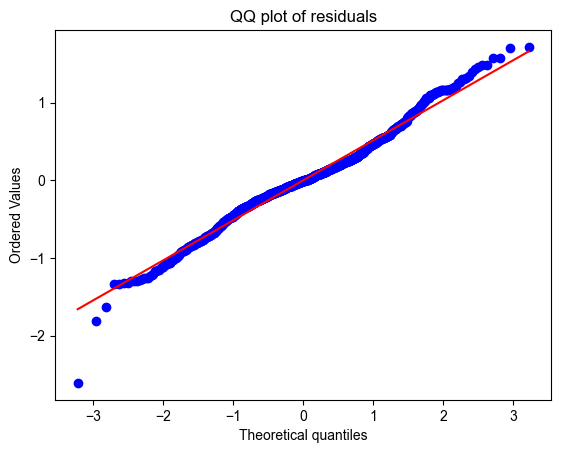

In [64]:
import matplotlib.pyplot as plt
import scipy.stats as stats

resid = fit.resid

stats.probplot(resid, dist="norm", plot=plt)
plt.title("QQ plot of residuals")
plt.show()